# Import Environment variables

In [1]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [2]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [3]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importation des données issues du notebook `54_Breast_Cancer_WITHIN_5Y_DataSelectionAndFiltering`

In [4]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

name_of_file_in_bucket = "df_bcscRisk.tsv"

df_bcscRisk = pd.read_csv(my_bucket +'/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df_bcscRisk

,person_id,inclusion_date,first_breast_cancer_date,delay_days,age_at_inclusion,has_bc,eur_rye,eas_rye,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80,biopsy_result,age_category,race_us_bcsc,race_us_bcsc_detail,breast_cancer_family_history_first_degree,score_bcscRisk
0,1700611,2019-09-17,NaN,NaN,70.255989,0,0.091868,0.000000,0.000000,0.848348,0.000000,0.059785,afr_rye,afr_rye,0,72,2,afr_rye,0,0.016274
1,1356439,2019-03-04,NaN,NaN,69.716632,0,0.065172,0.000000,0.025094,0.000000,0.809500,0.100234,sas_rye,sas_rye,0,67,3,eas_rye/sas_rye,0,0.014183
2,3451057,2023-01-18,NaN,NaN,71.594798,0,0.103268,0.000000,0.037591,0.000000,0.847168,0.011974,sas_rye,sas_rye,0,72,3,eas_rye/sas_rye,0,0.014737
3,1559161,2019-03-11,NaN,NaN,67.737166,0,0.006018,0.006429,0.965105,0.000000,0.022449,0.000000,amr_rye,amr_rye,0,67,8,amr_rye/mid_rye,0,0.016789
4,1468526,2019-10-07,NaN,NaN,63.310062,0,0.896282,0.000000,0.032661,0.000000,0.071057,0.000000,eur_rye,eur_rye,0,62,1,eur_rye,0,0.016168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124896,4386725,2023-05-11,NaN,NaN,40.903491,0,0.894660,0.000000,0.045839,0.000000,0.059501,0.000000,eur_rye,eur_rye,1,42,1,eur_rye,0,0.007283
124897,2743914,2022-08-08,NaN,NaN,40.147844,0,0.980679,0.000000,0.000000,0.000000,0.019321,0.000000,eur_rye,eur_rye,0,42,1,eur_rye,0,0.005087
124898,1475516,2022-07-06,NaN,NaN,40.057495,0,0.848439,0.000000,0.049838,0.000000,0.033280,0.068442,eur_rye,eur_rye,0,42,1,eur_rye,0,0.005087
124899,9915233,2022-09-14,NaN,NaN,40.249144,0,0.673153,0.000000,0.050596,0.000000,0.000000,0.276251,eur_rye,eur / mid,0,42,1,eur_rye,0,0.005087


In [5]:
df_bcscRisk[(df_bcscRisk['person_id'] > 2445350) & (df_bcscRisk['person_id'] < 2445400)]

,person_id,inclusion_date,first_breast_cancer_date,delay_days,age_at_inclusion,has_bc,eur_rye,eas_rye,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80,biopsy_result,age_category,race_us_bcsc,race_us_bcsc_detail,breast_cancer_family_history_first_degree,score_bcscRisk
12127,2445397,2018-09-13,NaN,NaN,66.245038,0,0.316583,0.018889,0.16686,0.354099,0.0,0.143569,afr_rye,admixed,0,67,2,afr_rye,0,0.015663


# Calcul du score Mammorisk®

## Import Mammorisk®

In [6]:
pip install pycryptodome

Note: you may need to restart the kernel to use updated packages.


In [7]:
import getpass
import io
from Crypto.Cipher import AES
from Crypto.Protocol.KDF import PBKDF2

In [8]:
def load_encrypted_csv(enc_file_path, password):
    with open(enc_file_path, "rb") as f:
        salt = f.read(16)
        nonce = f.read(16)
        tag = f.read(16)
        ciphertext = f.read()

    # Dériver la même clé
    key = PBKDF2(password, salt, dkLen=32, count=100000)

    # Déchiffrer
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    decrypted_data = cipher.decrypt_and_verify(ciphertext, tag)

    # Charger directement dans Pandas via RAM
    return pd.read_csv(io.BytesIO(decrypted_data))

In [9]:
# Usage
my_encrypt_file= "Datas/mammorisk_encrypted_remi.enc"

password = getpass.getpass("Entrez le mot de passe MammoRisk : ")
df_mammorisk = load_encrypted_csv(my_encrypt_file, password)
print("✅ Fichier chargé en mémoire RAM ! Shape :", df_mammorisk.shape)

Entrez le mot de passe MammoRisk :  ········


✅ Fichier chargé en mémoire RAM ! Shape : (210, 5)


## Application du modèle Mammorisk®

In [10]:
df_bcscRisk.rename(columns={"biopsy_result": "biopsy"}, inplace=True)

In [11]:
# 1. Vérification/Harmonisation des noms de colonnes dans All of Us
# On s'assure que les colonnes de jointure ont des types identiques (int)
join_keys = [
    "age_category",
    "race_us_bcsc",
    "breast_cancer_family_history_first_degree",
    "biopsy",
]

# 2. Application de la jointure (merge) pour récupérer le score
df_bcscRisk_Mammorisk = (df_bcscRisk.merge(df_mammorisk, on=join_keys, how="left"))

In [12]:
df_bcscRisk_Mammorisk.rename(columns={"score_knn_v27_weighted_average_breast_density": "score_mammorisk"}, inplace=True)

In [13]:
# 4. Vérification de l'application
missing_scores = df_bcscRisk_Mammorisk["score_mammorisk"].isna().sum()
print(f"Nombre d'individus avec un score MammoRisk attribué : {len(df_bcscRisk_Mammorisk) - missing_scores}")
print(f"Nombre de scores manquants (échec de jointure) : {missing_scores}")

Nombre d'individus avec un score MammoRisk attribué : 124901
Nombre de scores manquants (échec de jointure) : 0


<Axes: ylabel='Frequency'>

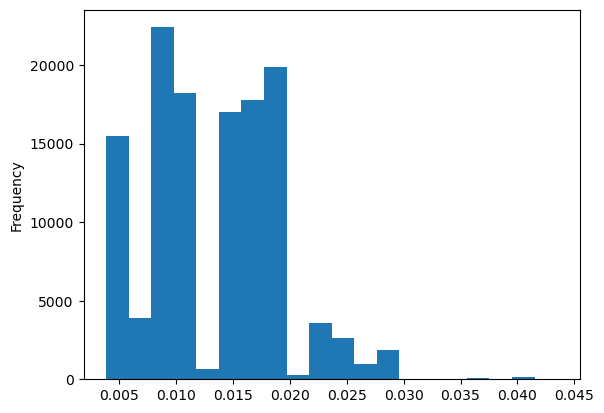

In [14]:
df_bcscRisk_Mammorisk["score_mammorisk"].plot.hist(bins=20)

# Evaluation de performance du modèle Mammorisk®

## Evaluation globale

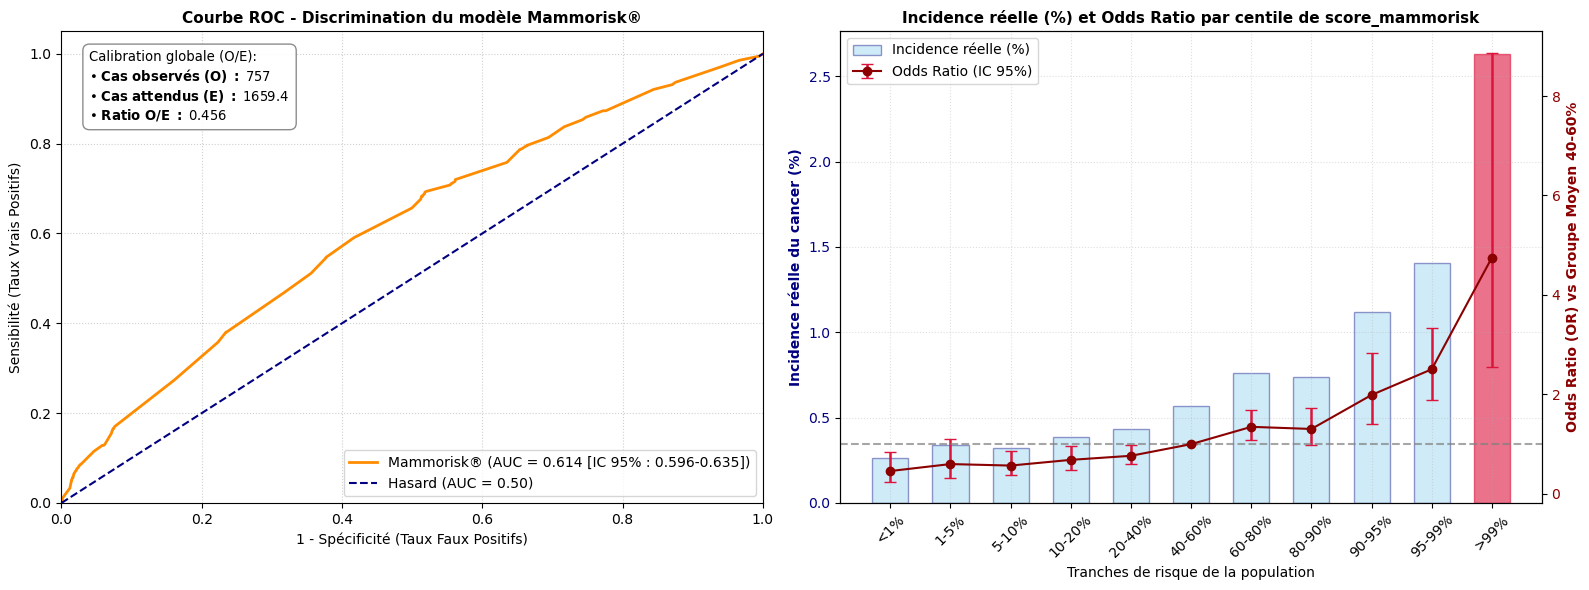

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve

# 1. Nettoyage des données
df_eval = df_bcscRisk_Mammorisk.dropna(subset=["has_bc", "score_mammorisk"]).copy()

y_true = df_eval["has_bc"]
y_scores = df_eval["score_mammorisk"]

# -------------------------------------------------------------------------
# A. Calcul de l'AUC-ROC et IC 95% (Bootstrap)
# -------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)


def bootstrap_auc(y_true, y_scores, n_bootstraps=1000, rng_seed=42):
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true)
    y_scores_arr = np.array(y_scores)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


ci_lower, ci_upper = bootstrap_auc(y_true, y_scores)

# -------------------------------------------------------------------------
# B. Ratio O/E (Observed / Expected)
# -------------------------------------------------------------------------
observed_cases = int(y_true.sum())
expected_cases = float(y_scores.sum())
oe_ratio = observed_cases / expected_cases

# -------------------------------------------------------------------------
# C. Calcul des quantiles, de l'incidence et des Odds Ratios
# -------------------------------------------------------------------------
quantiles = [
    0.0,
    0.01,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.99,
    1.0,
]
labels = [
    "<1%",
    "1-5%",
    "5-10%",
    "10-20%",
    "20-40%",
    "40-60%",
    "60-80%",
    "80-90%",
    "90-95%",
    "95-99%",
    ">99%",
]

df_eval["risk_group"] = pd.cut(
    df_eval["score_mammorisk"],
    bins=df_eval["score_mammorisk"].quantile(quantiles),
    labels=labels,
    include_lowest=True,
)

# 1. Calcul de l'incidence réelle (%)
incidence = df_eval.groupby("risk_group", observed=False)["has_bc"].agg(
    ["mean", "count"]
)
incidence["pct"] = incidence["mean"] * 100
incidence = incidence.reindex(labels)

# 2. Calcul des Odds Ratios par régression logistique (référence = '40-60%')
dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)
ref_col = "40-60%"
X = dummies.drop(columns=[ref_col]).astype(int)
X = sm.add_constant(X)

logit_mod = sm.Logit(y_true, X).fit(disp=False)
conf = logit_mod.conf_int()

or_df = pd.DataFrame(
    {
        "OR": np.exp(logit_mod.params),
        "lower": np.exp(conf[0]),
        "upper": np.exp(conf[1]),
    }
)
or_df.loc["const"] = [1.0, 1.0, 1.0]
or_df.index = [c if c != "const" else ref_col for c in or_df.index]
or_df = or_df.reindex(labels)

# -------------------------------------------------------------------------
# D. Affichage des deux sous-graphiques côte à côte
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : ROC ---
axes[0].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Mammorisk® (AUC = {roc_auc:.3f} [IC 95% : {ci_lower:.3f}-{ci_upper:.3f}])",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--",
    label="Hasard (AUC = 0.50)",
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
axes[0].set_title(
    "Courbe ROC - Discrimination du modèle Mammorisk®", fontsize=11, fontweight="bold"
)
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# AJOUT DU CARTOUCHE DE CALIBRATION DANS LE SUBPLOT ROC
text_str = (
    r"Calibration globale (O/E):"
    "\n"
    rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
    "\n"
    rf"• $\mathbf{{Cas\ attendus\ (E)\ :}}$ {expected_cases:.1f}"
    "\n"
    rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_ratio:.3f}"
)

axes[0].text(
    0.04,
    0.96,
    text_str,
    transform=axes[0].transAxes,
    fontsize=9.5,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

# --- Graphique 2 : Combiné (Incidence % [Barres] + OR [Ligne/Points]) ---
x_pos = np.arange(len(labels))

# Axe Y principal (Gauche) : Incidence en %
bars = axes[1].bar(
    x_pos,
    incidence["pct"],
    alpha=0.4,
    color="skyblue",
    edgecolor="navy",
    width=0.6,
    label="Incidence réelle (%)",
)
# Mise en valeur du dernier centile (>99%)
bars[-1].set_color("crimson")
bars[-1].set_alpha(0.6)

axes[1].set_xlabel("Tranches de risque de la population", fontsize=10)
axes[1].set_ylabel(
    "Incidence réelle du cancer (%)",
    fontsize=10,
    color="navy",
    fontweight="bold",
)
axes[1].tick_params(axis="y", labelcolor="navy")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].grid(True, linestyle=":", alpha=0.4)

# Axe Y secondaire (Droite) : Odds Ratios
ax2 = axes[1].twinx()
line_or = ax2.errorbar(
    x_pos,
    or_df["OR"],
    yerr=[or_df["OR"] - or_df["lower"], or_df["upper"] - or_df["OR"]],
    fmt="o-",
    color="darkred",
    ecolor="crimson",
    elinewidth=1.8,
    capsize=4,
    markersize=6,
    label="Odds Ratio (IC 95%)",
)
ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
ax2.set_ylabel(
    "Odds Ratio (OR) vs Groupe Moyen 40-60%",
    fontsize=10,
    color="darkred",
    fontweight="bold",
)
ax2.tick_params(axis="y", labelcolor="darkred")

# Légende combinée pour le graphique 2
lines_1, labels_1 = axes[1].get_legend_handles_labels()
axes[1].legend(
    lines_1 + [line_or],
    labels_1 + ["Odds Ratio (IC 95%)"],
    loc="upper left",
    frameon=True,
)

axes[1].set_title(
    "Incidence réelle (%) et Odds Ratio par centile de score_mammorisk",
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

1. **AUC-ROC (Area Under the ROC Curve) :** Évalue la capacité globale de discrimination.
    * **Si l'AUC est comprise entre $0,60$ et $0,68$ :** C'est la performance clinique standard attendue pour les modèles épidémiologiques de première génération (BCSC, Gail, Tyrer-Cuzick sans génétique ni densité). Dans l'article d'Elie Rassy et al., les scores cliniques seuls se situent exactement dans cette zone avant l'ajout du score de risque polygénique (PRS).
3. **Courbe ROC :** Visualisation du compromis entre sensibilité et spécificité.
4. **Courbe de Calibration :** Compare le risque moyen prédit au taux de cancer réel par décile de risque.
5. **Ratio O/E (Observed / Expected) :** Évalue la sur-estimation ou sous-estimation globale du modèle.
    * Interprétation du Ratio O/E :
      * $\text{O/E} \approx 1,0$ : Le modèle est parfaitement calibré sur la cohorte.
      * $\text{O/E} < 1,0$ : Le modèle sur-estime le risque réel dans All of Us.
      * $\text{O/E} > 1,0$ : Le modèle sous-estime le risque.

## Evaluation selon l'ethnie


==================== Analyse pour : afr_rye ====================


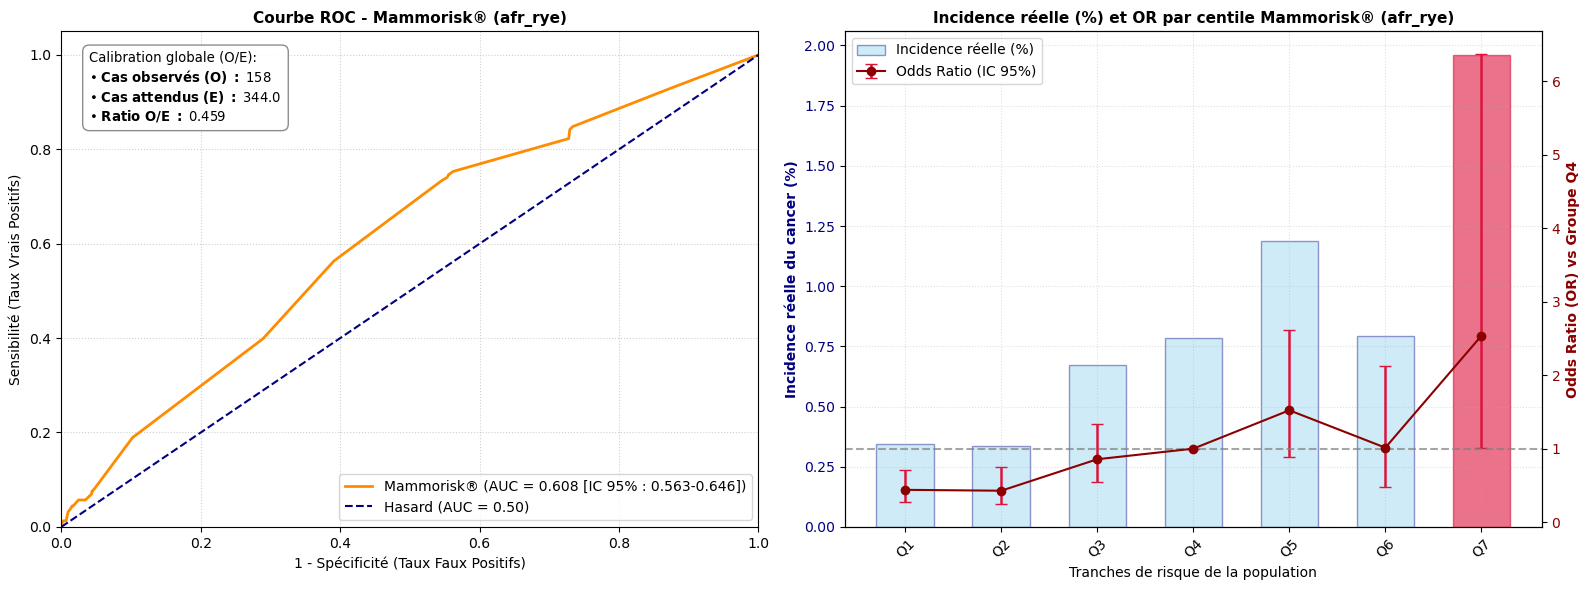


==================== Analyse pour : eas_rye/sas_rye ====================


/opt/conda/envs/jupyter/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


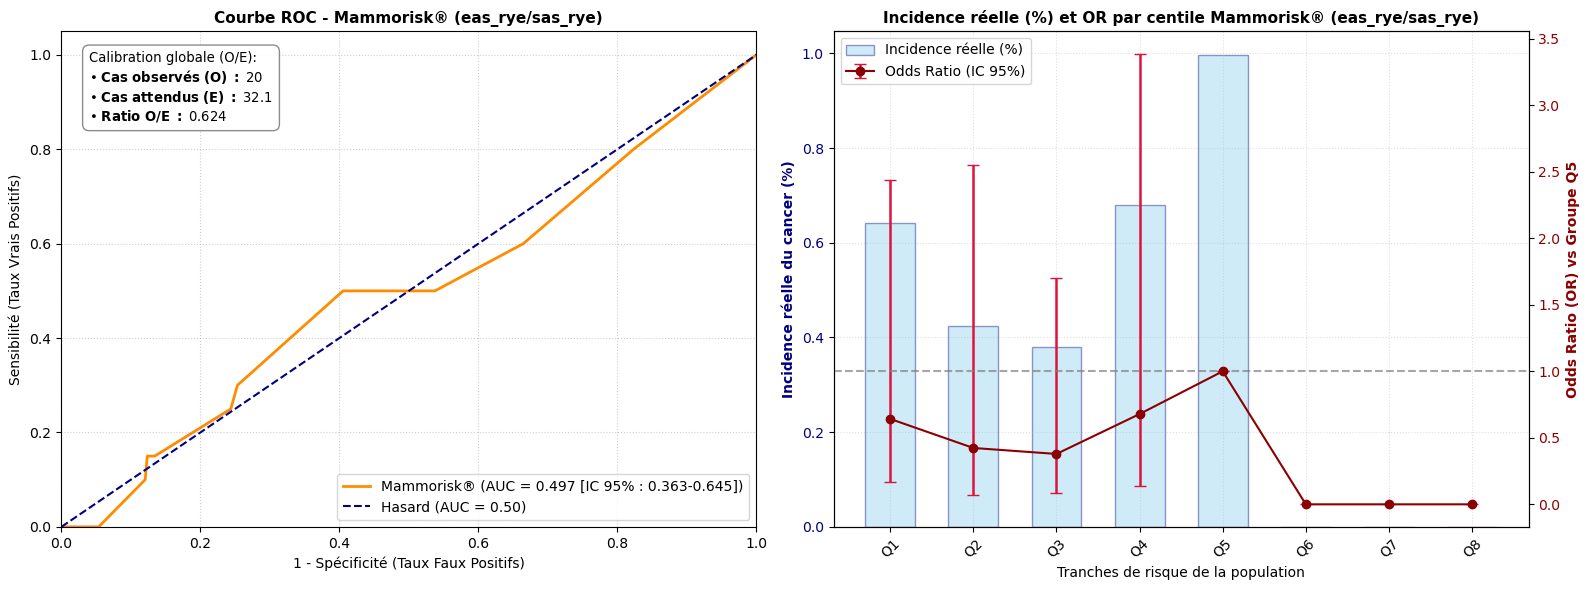


==================== Analyse pour : amr_rye/mid_rye ====================


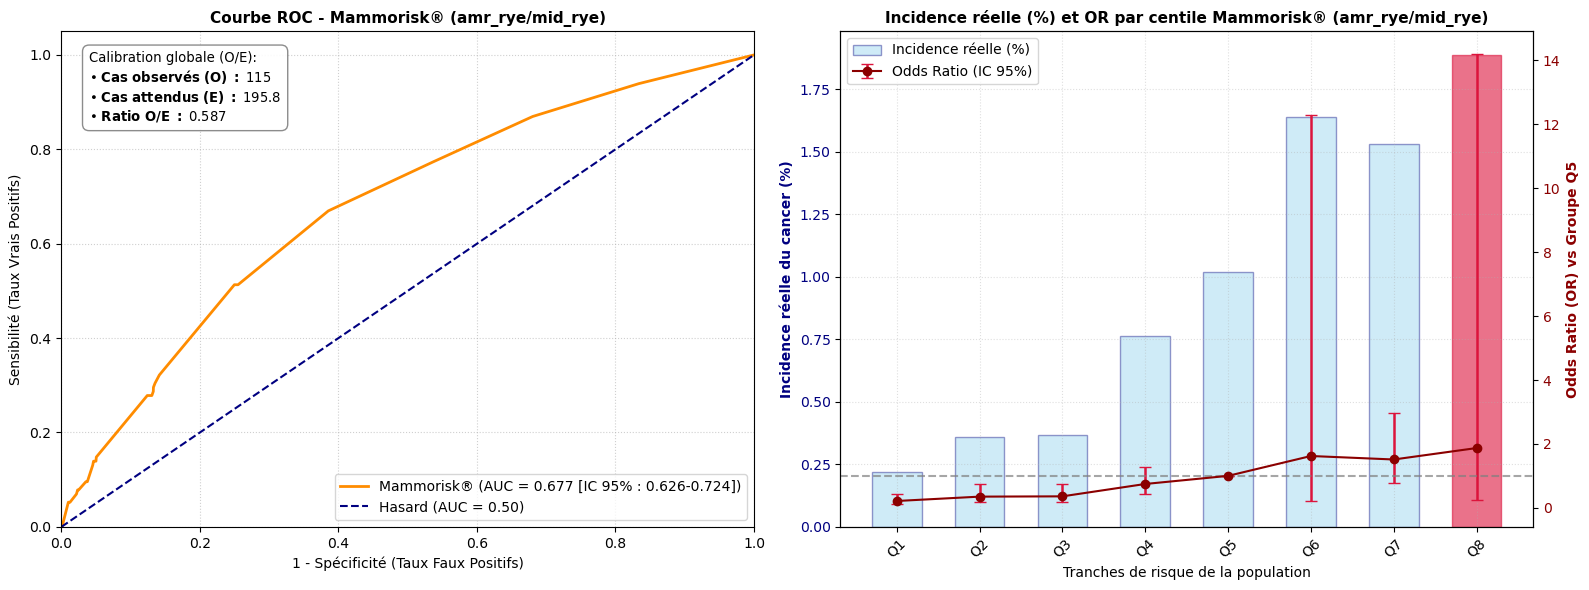


==================== Analyse pour : eur_rye ====================


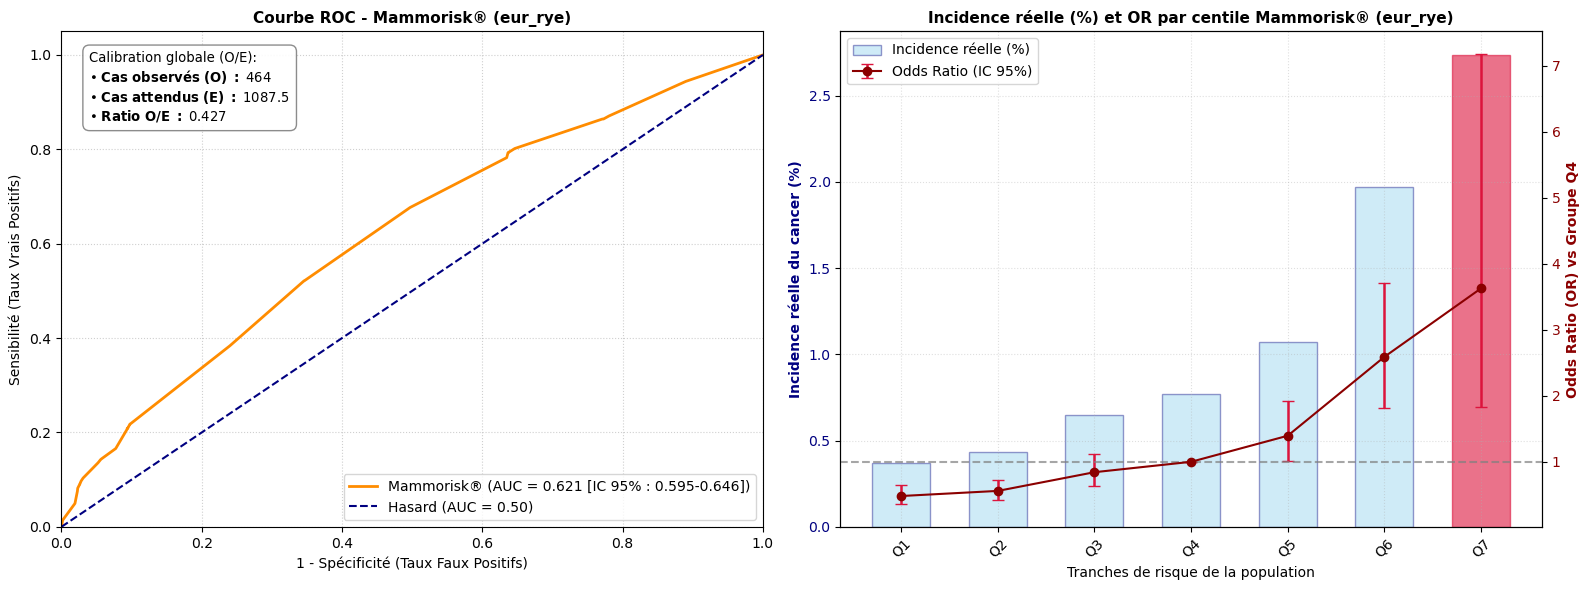

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve


# 1. Définition de la fonction Bootstrap hors de la boucle
def bootstrap_auc(y_true, y_scores, n_bootstraps=1000, rng_seed=42):
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true)
    y_scores_arr = np.array(y_scores)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    if len(bootstrapped_scores) == 0:
        return np.nan, np.nan

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


# 2. Liste des origines/ethnies uniques
ethnies = list(df_bcscRisk_Mammorisk["race_us_bcsc_detail"].dropna().unique())

for i in ethnies:
    print(f"\n==================== Analyse pour : {i} ====================")

    # Filtrage et copie propre
    df_sub = df_bcscRisk_Mammorisk[df_bcscRisk_Mammorisk["race_us_bcsc_detail"] == i]
    df_eval = df_sub.dropna(subset=["has_bc", "score_mammorisk"]).copy()

    y_true = df_eval["has_bc"]
    y_scores = df_eval["score_mammorisk"]

    # Sécurité : Vérifier qu'il y a assez de données et au moins 1 cas + 1 contrôle
    if len(df_eval) < 10 or len(np.unique(y_true)) < 2:
        print(
            f"[SKIP] Pas assez d'échantillons ou de cas de cancer pour"
            f" l'ethnie : {i}"
        )
        continue

    # A. Calcul de l'AUC-ROC et IC 95%
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    ci_lower, ci_upper = bootstrap_auc(y_true, y_scores)

    # B. Ratio O/E
    observed_cases = int(y_true.sum())
    expected_cases = float(y_scores.sum())
    oe_ratio = (
        observed_cases / expected_cases if expected_cases > 0 else np.nan
    )

    # C. Calcul des quantiles dynamiques et sécurisés
    quantiles = [
        0.0,
        0.01,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1.0,
    ]
    labels_11 = [
        "<1%",
        "1-5%",
        "5-10%",
        "10-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-90%",
        "90-95%",
        "95-99%",
        ">99%",
    ]

    # Calcul des bornes de quantiles réelles sur les données du groupe
    bins = df_eval["score_mammorisk"].quantile(quantiles).unique()

    # Si la variabilité est trop faible pour créer au moins 2 tranches
    if len(bins) < 2:
        print(f"[SKIP] Variabilité de score insuffisante pour l'ethnie : {i}")
        continue

    # Découpage robuste avec les bornes uniques trouvées
    if len(bins) == len(quantiles):
        current_labels = labels_11
    else:
        # Si des bornes identiques ont été fusionnées
        current_labels = [f"Q{k+1}" for k in range(len(bins) - 1)]

    df_eval["risk_group"] = pd.cut(
        df_eval["score_mammorisk"],
        bins=bins,
        labels=current_labels,
        include_lowest=True,
    )

    # Liste des catégories réellement présentes
    used_labels = [
        cat for cat in current_labels if cat in df_eval["risk_group"].values
    ]

    # 1. Calcul de l'incidence réelle (%)
    incidence = df_eval.groupby("risk_group", observed=False)["has_bc"].agg(
        ["mean", "count"]
    )
    incidence["pct"] = incidence["mean"] * 100
    incidence = incidence.loc[used_labels]

    # 2. Calcul des Odds Ratios
    dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)

    # Choix de la catégorie de référence
    ref_col = (
        "40-60%"
        if "40-60%" in dummies.columns
        else dummies.columns[len(dummies.columns) // 2]
    )

    X = dummies.drop(columns=[ref_col]).astype(int)
    X = sm.add_constant(X)

    try:
        logit_mod = sm.Logit(y_true, X).fit(disp=False)
        conf = logit_mod.conf_int()

        or_df = pd.DataFrame(
            {
                "OR": np.exp(logit_mod.params),
                "lower": np.exp(conf[0]),
                "upper": np.exp(conf[1]),
            }
        )
        or_df.loc["const"] = [1.0, 1.0, 1.0]
        or_df.index = [c if c != "const" else ref_col for c in or_df.index]
        or_df = or_df.reindex(used_labels)
    except Exception as e:
        print(f"[WARN] Régression logistique échec pour {i} : {e}")
        or_df = pd.DataFrame(
            index=used_labels, columns=["OR", "lower", "upper"]
        )

    # D. Affichage des graphiques pour l'ethnie courante
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Subplot 1 : ROC ---
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=(
            f"Mammorisk® (AUC = {roc_auc:.3f} [IC 95% :"
            f" {ci_lower:.3f}-{ci_upper:.3f}])"
        ),
    )
    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--",
        label="Hasard (AUC = 0.50)",
    )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
    axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
    axes[0].set_title(
        f"Courbe ROC - Mammorisk® ({i})", fontsize=11, fontweight="bold"
    )
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # Cartouche texte
    text_str = (
        r"Calibration globale (O/E):"
        "\n"
        rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
        "\n"
        rf"• $\mathbf{{Cas\ attendus\ (E)\ :}}$ {expected_cases:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_ratio:.3f}"
    )

    axes[0].text(
        0.04,
        0.96,
        text_str,
        transform=axes[0].transAxes,
        fontsize=9.5,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9
        ),
    )

    # --- Subplot 2 : Incidence + OR ---
    x_pos = np.arange(len(used_labels))

    # Plot des barres d'incidence
    bars = axes[1].bar(
        x_pos,
        incidence["pct"],
        alpha=0.4,
        color="skyblue",
        edgecolor="navy",
        width=0.6,
        label="Incidence réelle (%)",
    )
    if len(bars) > 0:
        bars[-1].set_color("crimson")
        bars[-1].set_alpha(0.6)

    axes[1].set_xlabel("Tranches de risque de la population", fontsize=10)
    axes[1].set_ylabel(
        "Incidence réelle du cancer (%)",
        fontsize=10,
        color="navy",
        fontweight="bold",
    )
    axes[1].tick_params(axis="y", labelcolor="navy")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(used_labels, rotation=45)
    axes[1].grid(True, linestyle=":", alpha=0.4)

    # Plot des Odds Ratios sur l'axe secondaire Y
    ax2 = axes[1].twinx()

    # Retirer les NaN s'il y a eu un échec partiel de régression
    valid_or = or_df.dropna(subset=["OR"])
    valid_x = [used_labels.index(idx) for idx in valid_or.index]

    if not valid_or.empty:
        line_or = ax2.errorbar(
            valid_x,
            valid_or["OR"],
            yerr=[
                valid_or["OR"] - valid_or["lower"],
                valid_or["upper"] - valid_or["OR"],
            ],
            fmt="o-",
            color="darkred",
            ecolor="crimson",
            elinewidth=1.8,
            capsize=4,
            markersize=6,
            label="Odds Ratio (IC 95%)",
        )

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
    ax2.set_ylabel(
        f"Odds Ratio (OR) vs Groupe {ref_col}",
        fontsize=10,
        color="darkred",
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor="darkred")

    # Gestion propre de la légende combinée
    lines_1, labels_1 = axes[1].get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    axes[1].legend(
        lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True
    )

    axes[1].set_title(
        f"Incidence réelle (%) et OR par centile Mammorisk® ({i})",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

# Data's export

In [20]:
destination_filename = 'Datas/df_bcscRisk_Mammorisk.tsv'
df_bcscRisk_Mammorisk.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_bcscRisk_Mammorisk.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 22.4 MiB]                                                \r/ [1 files][ 22.4 MiB/ 22.4 MiB]                                                \r\nOperation completed over 1 objects/22.4 MiB.                                     \n'